In [4]:
!pip3 install numpy matplotlib plotly nbformat


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import matplotlib.pyplot as plt

   income  purchase_amount
0   40682            18249
1   15317             4557
2   38849            11822
3   11568             4098
4   46952            19685
[[40682 18249]
 [15317  4557]
 [38849 11822]
 ...
 [13222  5152]
 [40093 16312]
 [22249  9426]]


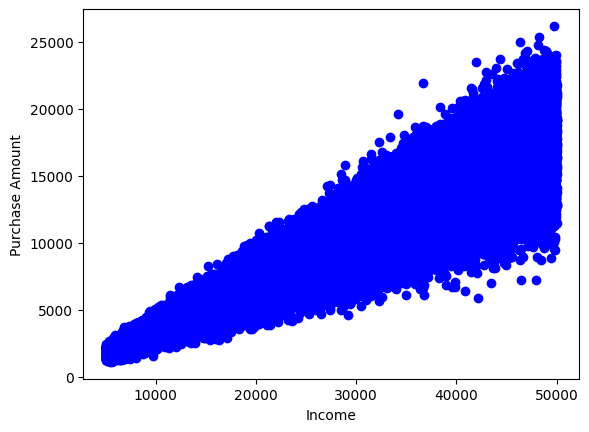

In [2]:
df = pd.read_csv("customer_data1.csv")

print(df[['income','purchase_amount']].head())
x = df[['income','purchase_amount']].to_numpy()
print(x)
plt.scatter(x[:,0], x[:,1], color='b')
plt.xlabel('Income')
plt.ylabel('Purchase Amount')
plt.show()

In [3]:
class KMeans:
    def __init__(self, n_clusters, data):
        self.k = n_clusters
        self.x = data  # Đảm bảo dữ liệu là numpy.ndarray
        self.d = self.x[0].shape[0]  # Số chiều dữ liệu
        self.centroids = np.zeros((self.k, self.d))

        # Khởi tạo centroid ngẫu nhiên trong phạm vi dữ liệu
        for i in range(self.d):
            self.centroids[:, i] = np.random.uniform(np.min(self.x[:, i]), np.max(self.x[:, i]), size=self.k)

        self.labels = self.genLabels()
        self.colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'black', 4: 'purple', 5: 'orange', 6: 'brown'}

    def dist(self, p, q):
        return math.sqrt(np.sum(np.power(np.subtract(p, q), 2)))  # Khoảng cách Euclidean

    def predict(self, p):
        return np.argmin([self.dist(p, centroid) for centroid in self.centroids])

    def genLabels(self):
        return np.array([self.predict(p) for p in self.x])

    def fit(self, epochs, step):
        print(f"\nFitting for {epochs} epochs with step of {step}")
        for epoch in range(epochs):
            for i, centroid in enumerate(self.centroids):
                l = np.array([1 if item == i else 0 for item in self.labels])
                
                if np.sum(l) > 0:  # Tránh lỗi chia cho 0
                    temp = np.sum((self.x - centroid) * l[:, np.newaxis], axis=0) / np.sum(l)
                    self.centroids[i] += step * temp

            # Cập nhật nhãn mới
            self.labels = self.genLabels()

        print("Done fitting!\n")

    def showPlot(self, classification=False):
        plt.figure(figsize=(10, 10))

        if classification:
            handles = []  # Danh sách biểu tượng cho chú thích

            for i, p in enumerate(self.x):
                plt.scatter(p[0], p[1], color=self.colors[self.labels[i]])

            for i, centroid in enumerate(self.centroids):
                plt.scatter(centroid[0], centroid[1], color=self.colors[i], s=100, marker="x")
                
                # Thêm vào danh sách chú thích
                handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                        markerfacecolor=self.colors[i], markersize=10,
                                        label=f"Cluster {i}"))

            # Hiển thị chú thích ở góc trên bên trái
            plt.legend(handles=handles, loc="upper left", title="Clusters")

        else:
            plt.scatter(self.x[:, 0], self.x[:, 1], color='blue')
            plt.scatter(self.centroids[:, 0], self.centroids[:, 1], color="red", s=100)

        plt.show()


    def printCentroids(self):
        print("=" * 20)
        print("Centroids:")
        print(self.centroids)

    def calculate_wcss(self):
        return np.sum((self.x - self.centroids[self.labels]) ** 2)


In [6]:
class KMeans:
    def __init__(self, n_clusters, data):
        self.k = n_clusters
        self.x = np.array(data)  # Đảm bảo dữ liệu là numpy.ndarray
        self.d = self.x.shape[1]  # Số chiều dữ liệu
        self.centroids = np.zeros((self.k, self.d))

        # Khởi tạo centroid ngẫu nhiên trong phạm vi dữ liệu
        for i in range(self.d):
            self.centroids[:, i] = np.random.uniform(np.min(self.x[:, i]), np.max(self.x[:, i]), size=self.k)

        self.labels = self.genLabels()
        self.colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'black', 4: 'purple', 5: 'orange', 6: 'brown'}

    def dist(self, p, q):
        return np.linalg.norm(p - q)  # Khoảng cách Euclidean

    def predict(self, p):
        return np.argmin([self.dist(p, centroid) for centroid in self.centroids])

    def genLabels(self):
        return np.array([self.predict(p) for p in self.x])

    def fit(self, epochs, step):
        print(f"\nFitting for {epochs} epochs with step of {step}")
        for epoch in range(epochs):
            for i, centroid in enumerate(self.centroids):
                l = np.array([1 if item == i else 0 for item in self.labels])
                
                if np.sum(l) > 0:  # Tránh lỗi chia cho 0
                    temp = np.sum((self.x - centroid) * l[:, np.newaxis], axis=0) / np.sum(l)
                    self.centroids[i] += step * temp

            # Cập nhật nhãn mới
            self.labels = self.genLabels()

        print("Done fitting!\n")

    def showPlot(self, classification=False):
        plt.figure(figsize=(10, 10))

        if classification:
            handles = []  # Danh sách biểu tượng cho chú thích

            for i, p in enumerate(self.x):
                plt.scatter(p[0], p[1], color=self.colors[self.labels[i]])

            for i, centroid in enumerate(self.centroids):
                plt.scatter(centroid[0], centroid[1], color=self.colors[i], s=100, marker="x")
                
                # Thêm vào danh sách chú thích
                handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                        markerfacecolor=self.colors[i], markersize=10,
                                        label=f"Cluster {i}"))

            # Hiển thị chú thích ở góc trên bên trái
            plt.legend(handles=handles, loc="upper left", title="Clusters")

        else:
            plt.scatter(self.x[:, 0], self.x[:, 1], color='blue')
            plt.scatter(self.centroids[:, 0], self.centroids[:, 1], color="red", s=100)

        plt.show()
    def printCentroids(self):
        print("=" * 20)
        print("Centroids:")
        print(self.centroids)

    def calculate_wcss(self):
        return np.sum((self.x - self.centroids[self.labels]) ** 2)


In [7]:
def elbow_curve(X, max_k):
    wcss_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, data=X)
        kmeans.fit(epochs=100, step=1)  # Fit the model
        wcss = kmeans.calculate_wcss()    # Calculate WCSS for this k
        wcss_values.append(wcss)

    # Plotting the elbow curve
    plt.plot(range(1, max_k + 1), wcss_values, marker='o', color='b')
    plt.title('Elbow Curve')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.show()


In [6]:
elbow_curve(x,8)


Fitting for 100 epochs with step of 1


KeyboardInterrupt: 

In [ ]:
kmeans = KMeans(n_clusters=3, data=x)
kmeans.showPlot(classification=True)
kmeans.printCentroids()
kmeans.fit(epochs=100, step=1)
pred = kmeans.genLabels()
print(pred)
kmeans.printCentroids()
kmeans.showPlot(classification=True)

KeyboardInterrupt: 